Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Set Dataset Path

In [ ]:
train_path = "/content/drive/MyDrive/Leaf_Dataset/CroppedMedLeaves/CroppedMedLeaves/train"
test_path  = "/content/drive/MyDrive/Leaf_Dataset/CroppedMedLeaves/CroppedMedLeaves/test"

Verify Dataset


In [ ]:
import os

print("Checking dataset structure...\n")

print("Train path exists:", os.path.exists(train_path))
print("Test path exists:", os.path.exists(test_path))

train_classes = os.listdir(train_path)
test_classes = os.listdir(test_path)

print("\n📁 Train classes (first 10):", train_classes[:10])
print("📁 Test classes (first 10):", test_classes[:10])

print("\n🔢 Total classes (train):", len(train_classes))
print("🔢 Total classes (test):", len(test_classes))

sample_class = train_classes[0]
sample_path = os.path.join(train_path, sample_class)

print(f"\n📂 Sample class: {sample_class}")
print("Number of images in this class:", len(os.listdir(sample_path)))

print("\n🖼️ Sample images:")
print(os.listdir(sample_path)[:5])

Checking dataset structure...

Train path exists: True
Test path exists: True

📁 Train classes (first 10): ['9', '7', '27', '24', '22', '23', '5', '8', '6', '26']
📁 Test classes (first 10): ['8', '9', '4', '6', '5', '7', '29', '28', '3', '26']

🔢 Total classes (train): 30
🔢 Total classes (test): 30

📂 Sample class: 9
Number of images in this class: 2475

🖼️ Sample images:
['2023_08_25_16_44_IMG_1153_JPG_jpg.rf.735b44f0fc641b1481e7018d74e411b8.jpg_cropped_9_class9.jpg', '2023_08_25_16_44_IMG_1154_JPG_jpg.rf.173501eabc35469d1f88627d1bf09d47.jpg_cropped_4_class9.jpg', '2023_08_25_16_44_IMG_1157_JPG_jpg.rf.fde9bc14f80a21bb6162925fed56bc8f.jpg_cropped_2_class9.jpg', '2023_08_25_16_45_IMG_1158_JPG_jpg.rf.4be95d0c1ea88d6ce7f02682f486cf8d.jpg_cropped_1_class9.jpg', '2023_08_25_16_44_IMG_1157_JPG_jpg.rf.3dd544610008b28bd93eaeac25756e1b.jpg_cropped_8_class9.jpg']


Import libraries


In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.applications import VGG16, InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Set dataset path

Preprocessing of Image


In [ ]:
img_size = (128, 128)
batch_size = 16

train_gen = ImageDataGenerator(rescale=1./255)
test_gen  = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 54454 images belonging to 30 classes.
Found 4086 images belonging to 30 classes.


VGG16 Model


In [ ]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))

for layer in vgg_base.layers:
    layer.trainable = False

vgg_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Train VGG16 Model

In [ ]:
vgg_history = vgg_model.fit(
    train_data,
    validation_data=test_data,
    epochs=3,
    steps_per_epoch=200,
    validation_steps=50
)

Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 1372s 7s/step - accuracy: 0.6109 - loss: 1.4393 - val_accuracy: 0.7300 - val_loss: 0.9128
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 1212s 6s/step - accuracy: 0.8241 - loss: 0.6269 - val_accuracy: 0.8388 - val_loss: 0.5228
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 1074s 5s/step - accuracy: 0.8788 - loss: 0.4286 - val_accuracy: 0.8763 - val_loss: 0.4289


**Evaluate VGG16**

In [ ]:
vgg_loss, vgg_acc = vgg_model.evaluate(test_data)
print(f"VGG16 Model Accuracy: {vgg_acc*100:.2f}%")

256/256 ━━━━━━━━━━━━━━━━━━━━ 708s 3s/step - accuracy: 0.8793 - loss: 0.4127
VGG16 Model Accuracy: 87.93%


Inception V3 MODEL

In [ ]:
inc_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(128,128,3))

for layer in inc_base.layers:
    layer.trainable = False

inc_model = models.Sequential([
    inc_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

inc_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Train Inception V3

In [ ]:
inc_history = inc_model.fit(
    train_data,
    validation_data=test_data,
    epochs=2,
    steps_per_epoch=150,
    validation_steps=40
)

Epoch 1/2
150/150 ━━━━━━━━━━━━━━━━━━━━ 585s 4s/step - accuracy: 0.7496 - loss: 0.8943 - val_accuracy: 0.7328 - val_loss: 0.8957
Epoch 2/2
150/150 ━━━━━━━━━━━━━━━━━━━━ 551s 4s/step - accuracy: 0.7771 - loss: 0.7670 - val_accuracy: 0.7734 - val_loss: 0.8115


**Evaluate Inception V3**

In [ ]:
inc_loss, inc_acc = inc_model.evaluate(test_data)
print(f"Inception V3 Model Accuracy: {inc_acc*100:.2f}%")

256/256 ━━━━━━━━━━━━━━━━━━━━ 125s 489ms/step - accuracy: 0.7761 - loss: 0.7808
Inception V3 Model Accuracy: 77.61%


Comparison Graph

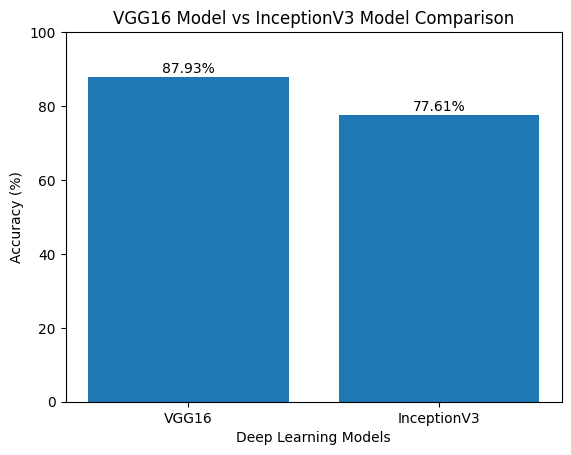

In [ ]:
models = ["VGG16", "InceptionV3"]
accuracies = [vgg_acc*100, inc_acc*100]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Deep Learning Models")
plt.ylabel("Accuracy (%)")
plt.title("VGG16 Model vs InceptionV3 Model Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')
plt.ylim(0, 100)
plt.show()